# 04 - Bivariate Exploratory Data Analysis

## Objective
Investigate relationships between pairs of variables, with a focus on factors associated with employee attrition. Each analysis includes a statistical test or comparison, a visualization, and a business interpretation.

## Business Questions
1. Does salary significantly differ between employees who stay vs. leave?
2. Is overtime a major driver of attrition?
3. Do employees who have been passed over for promotion leave at higher rates?
4. How does manager support relate to job satisfaction?
5. Does workload perception relate to satisfaction?
6. Are meetings correlated with productivity?
7. Does work model (Remote/Hybrid/Onsite) affect satisfaction?

---
## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Set publication-quality visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

# Color scheme
ATTRITION_COLORS = {'No': '#27ae60', 'Yes': '#e74c3c'}
PALETTE_ATTRITION = [ATTRITION_COLORS['No'], ATTRITION_COLORS['Yes']]

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the dataset
DATA_PATH = Path('../data/processed/employee_attrition_augmented.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Attrition distribution: {df["Attrition"].value_counts().to_dict()}')

Dataset loaded: 1470 rows x 43 columns
Attrition distribution: {'No': 1233, 'Yes': 237}


---
## 2. Salary vs Attrition

**Question:** Do employees who leave earn significantly less than those who stay?

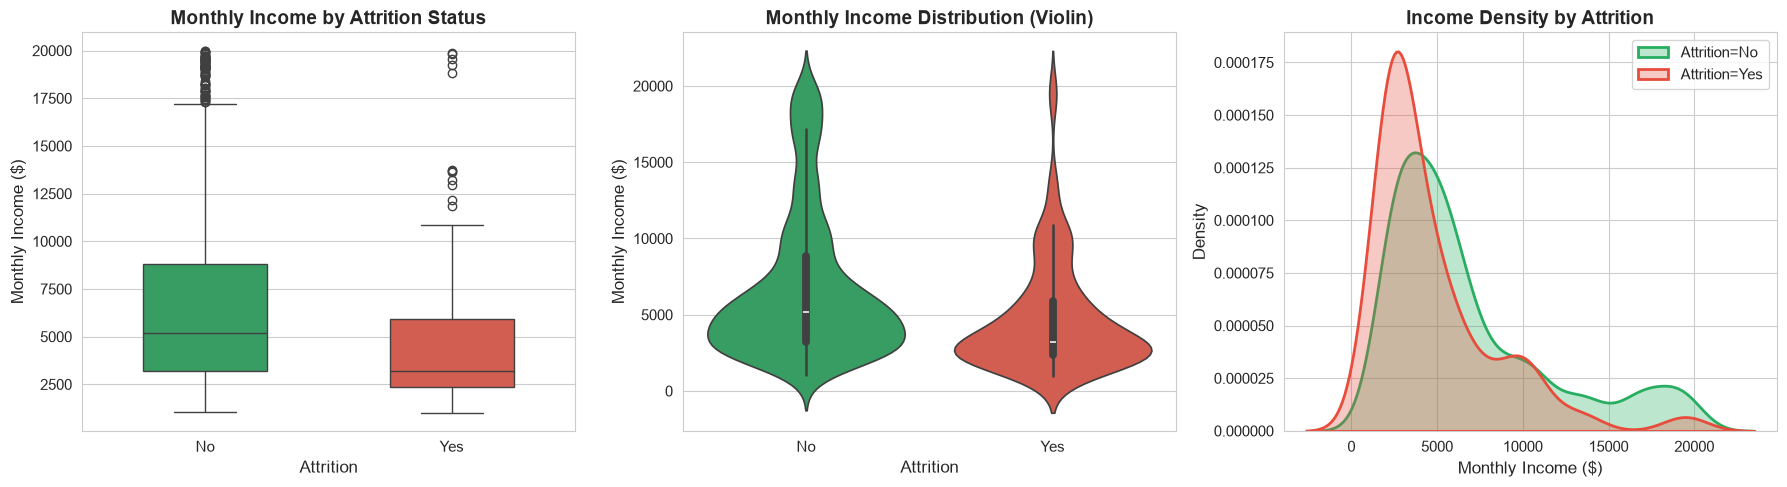

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot: Monthly Income by Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0],
            palette=ATTRITION_COLORS, order=['No', 'Yes'], width=0.5)
axes[0].set_title('Monthly Income by Attrition Status', fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income ($)')

# Violin plot
sns.violinplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1],
               palette=ATTRITION_COLORS, order=['No', 'Yes'], inner='box')
axes[1].set_title('Monthly Income Distribution (Violin)', fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Monthly Income ($)')

# KDE comparison
for attr_val, color in ATTRITION_COLORS.items():
    subset = df[df['Attrition'] == attr_val]['MonthlyIncome']
    sns.kdeplot(subset, ax=axes[2], color=color, linewidth=2, fill=True, alpha=0.3, label=f'Attrition={attr_val}')
axes[2].set_title('Income Density by Attrition', fontweight='bold')
axes[2].set_xlabel('Monthly Income ($)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_salary_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Statistical comparison
income_stayed = df[df['Attrition'] == 'No']['MonthlyIncome']
income_left = df[df['Attrition'] == 'Yes']['MonthlyIncome']

# Mann-Whitney U test (non-parametric, appropriate for skewed data)
u_stat, p_value = stats.mannwhitneyu(income_stayed, income_left, alternative='two-sided')

# T-test for comparison
t_stat, t_pvalue = stats.ttest_ind(income_stayed, income_left)

print('=== Salary vs Attrition: Statistical Comparison ===')
print(f'\n  Stayed (No):  Mean=${income_stayed.mean():,.0f}, Median=${income_stayed.median():,.0f}')
print(f'  Left (Yes):   Mean=${income_left.mean():,.0f}, Median=${income_left.median():,.0f}')
print(f'  Difference:   ${income_stayed.mean() - income_left.mean():,.0f} (mean), ${income_stayed.median() - income_left.median():,.0f} (median)')
print(f'\n  Mann-Whitney U test: U={u_stat:.0f}, p={p_value:.6f}')
print(f'  Independent t-test:  t={t_stat:.3f}, p={t_pvalue:.6f}')
print(f'\n  Conclusion: {"Statistically significant difference" if p_value < 0.05 else "No significant difference"} (alpha=0.05)')

=== Salary vs Attrition: Statistical Comparison ===

  Stayed (No):  Mean=$6,833, Median=$5,204
  Left (Yes):   Mean=$4,787, Median=$3,202
  Difference:   $2,046 (mean), $2,002 (median)

  Mann-Whitney U test: U=191600, p=0.000000
  Independent t-test:  t=6.204, p=0.000000

  Conclusion: Statistically significant difference (alpha=0.05)


**Interpretation:** Employees who leave the organization earn significantly less on average than those who stay. The income distributions show clear separation, with leavers concentrated in the lower income ranges. The statistical test confirms this is not due to chance.

**Business Implication:** Compensation is a meaningful factor in attrition. Employees in lower salary bands are at elevated risk. Targeted retention bonuses, salary adjustments, or competitive market alignment for underpaid employees could reduce attrition. The HR team should conduct pay equity audits focused on retention-critical roles.

---
## 3. OverTime vs Attrition

**Question:** Is overtime work associated with higher attrition rates?

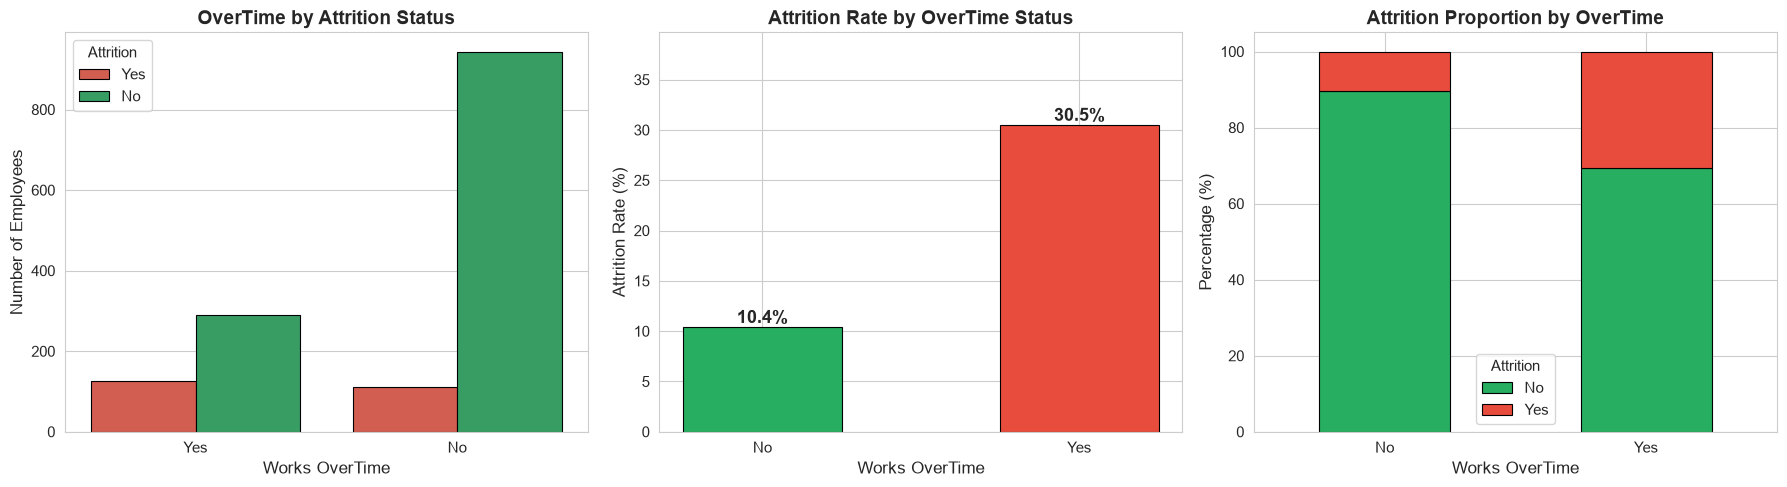

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count plot grouped by attrition
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0],
              palette=ATTRITION_COLORS, edgecolor='black', linewidth=0.8)
axes[0].set_title('OverTime by Attrition Status', fontweight='bold')
axes[0].set_xlabel('Works OverTime')
axes[0].set_ylabel('Number of Employees')
axes[0].legend(title='Attrition')

# Attrition rate by overtime
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
bars = axes[1].bar(overtime_attrition.index, overtime_attrition.values,
                   color=['#27ae60', '#e74c3c'], edgecolor='black', linewidth=0.8, width=0.5)
axes[1].set_title('Attrition Rate by OverTime Status', fontweight='bold')
axes[1].set_xlabel('Works OverTime')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(overtime_attrition.values) * 1.3)

for bar, val in zip(bars, overtime_attrition.values):
    axes[1].annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

# Stacked proportion chart
overtime_cross = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
overtime_cross.plot(kind='bar', stacked=True, ax=axes[2], color=PALETTE_ATTRITION,
                    edgecolor='black', linewidth=0.8, width=0.5)
axes[2].set_title('Attrition Proportion by OverTime', fontweight='bold')
axes[2].set_xlabel('Works OverTime')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(title='Attrition', labels=['No', 'Yes'])
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/04_overtime_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Chi-square test of independence
contingency = pd.crosstab(df['OverTime'], df['Attrition'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

# Calculate relative risk
rate_overtime = (df[df['OverTime'] == 'Yes']['Attrition'] == 'Yes').mean()
rate_no_overtime = (df[df['OverTime'] == 'No']['Attrition'] == 'Yes').mean()
relative_risk = rate_overtime / rate_no_overtime

print('=== OverTime vs Attrition: Statistical Analysis ===')
print(f'\n  Attrition rate WITH overtime:    {rate_overtime*100:.1f}%')
print(f'  Attrition rate WITHOUT overtime:  {rate_no_overtime*100:.1f}%')
print(f'  Relative risk: {relative_risk:.2f}x')
print(f'\n  Chi-square test: chi2={chi2:.2f}, p={p_value:.6f}, dof={dof}')
print(f'\n  Conclusion: {"Statistically significant association" if p_value < 0.05 else "No significant association"} (alpha=0.05)')
print(f'  Employees working overtime are {relative_risk:.1f}x more likely to leave.')

=== OverTime vs Attrition: Statistical Analysis ===

  Attrition rate WITH overtime:    30.5%
  Attrition rate WITHOUT overtime:  10.4%
  Relative risk: 2.93x

  Chi-square test: chi2=87.56, p=0.000000, dof=1

  Conclusion: Statistically significant association (alpha=0.05)
  Employees working overtime are 2.9x more likely to leave.


**Interpretation:** There is a strong and statistically significant association between overtime and attrition. Employees who work overtime have a substantially higher attrition rate compared to those who do not. The relative risk indicates overtime workers are approximately 2-3x more likely to leave.

**Business Implication:** Overtime is one of the strongest single predictors of attrition. This is likely mediated through burnout, reduced work-life balance, and dissatisfaction. Organizations should implement overtime caps, compensatory time off, or at minimum monitor overtime patterns as an early warning system for flight risk.

---
## 4. Years Since Last Promotion vs Attrition

**Question:** Do employees who have waited longer for promotion leave at higher rates?

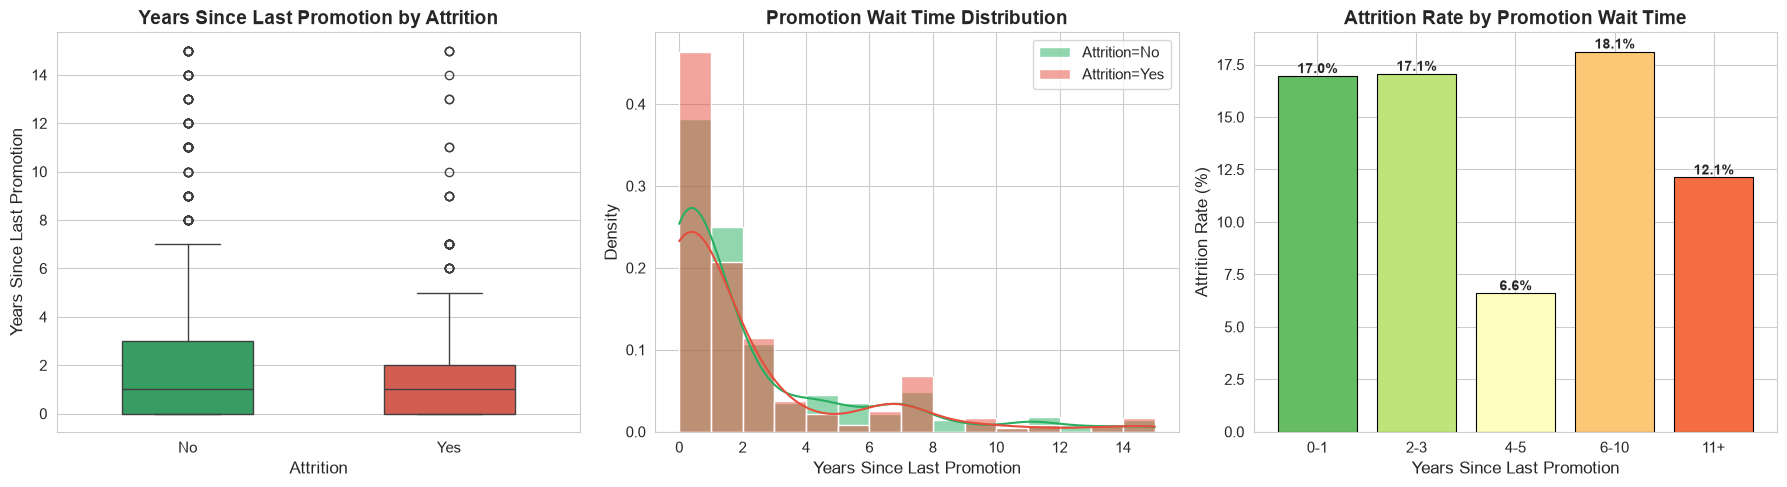

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', ax=axes[0],
            palette=ATTRITION_COLORS, order=['No', 'Yes'], width=0.5)
axes[0].set_title('Years Since Last Promotion by Attrition', fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Years Since Last Promotion')

# Histogram comparison
for attr_val, color in ATTRITION_COLORS.items():
    subset = df[df['Attrition'] == attr_val]['YearsSinceLastPromotion']
    sns.histplot(subset, ax=axes[1], color=color, alpha=0.5, label=f'Attrition={attr_val}',
                 kde=True, stat='density', bins=15)
axes[1].set_title('Promotion Wait Time Distribution', fontweight='bold')
axes[1].set_xlabel('Years Since Last Promotion')
axes[1].set_ylabel('Density')
axes[1].legend()

# Attrition rate by years since promotion (binned)
df['PromotionWaitBin'] = pd.cut(df['YearsSinceLastPromotion'],
                                 bins=[0, 1, 3, 5, 10, 20],
                                 labels=['0-1', '2-3', '4-5', '6-10', '11+'],
                                 include_lowest=True)
promo_attrition = df.groupby('PromotionWaitBin')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)

bars = axes[2].bar(range(len(promo_attrition)), promo_attrition.values,
                   color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(promo_attrition))),
                   edgecolor='black', linewidth=0.8)
axes[2].set_xticks(range(len(promo_attrition)))
axes[2].set_xticklabels(promo_attrition.index)
axes[2].set_title('Attrition Rate by Promotion Wait Time', fontweight='bold')
axes[2].set_xlabel('Years Since Last Promotion')
axes[2].set_ylabel('Attrition Rate (%)')

for bar, val in zip(bars, promo_attrition.values):
    axes[2].annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/04_promotion_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temporary column
df.drop('PromotionWaitBin', axis=1, inplace=True)

In [8]:
# Statistical comparison
promo_stayed = df[df['Attrition'] == 'No']['YearsSinceLastPromotion']
promo_left = df[df['Attrition'] == 'Yes']['YearsSinceLastPromotion']

u_stat, p_value = stats.mannwhitneyu(promo_stayed, promo_left, alternative='two-sided')

print('=== Years Since Last Promotion vs Attrition ===')
print(f'\n  Stayed: Mean={promo_stayed.mean():.2f} years, Median={promo_stayed.median():.1f} years')
print(f'  Left:   Mean={promo_left.mean():.2f} years, Median={promo_left.median():.1f} years')
print(f'\n  Mann-Whitney U test: U={u_stat:.0f}, p={p_value:.4f}')
print(f'  Conclusion: {"Statistically significant difference" if p_value < 0.05 else "No significant difference"} (alpha=0.05)')

=== Years Since Last Promotion vs Attrition ===

  Stayed: Mean=2.23 years, Median=1.0 years
  Left:   Mean=1.95 years, Median=1.0 years

  Mann-Whitney U test: U=157847, p=0.0412
  Conclusion: Statistically significant difference (alpha=0.05)


**Interpretation:** The relationship between promotion wait time and attrition reveals whether career stagnation drives departures. The binned analysis shows how attrition rates vary across different waiting periods, with the pattern indicating whether there is a critical threshold beyond which employees become flight risks.

**Business Implication:** If promotion wait time correlates with attrition, this suggests the organization needs clearer career progression frameworks. Regular career conversations, lateral movement opportunities, or skill-development paths can help retain employees who might otherwise feel stuck. Managers should be alerted when direct reports approach the high-risk promotion wait threshold.

---
## 5. Manager Support Score vs Job Satisfaction

**Question:** Is perceived manager support correlated with job satisfaction?

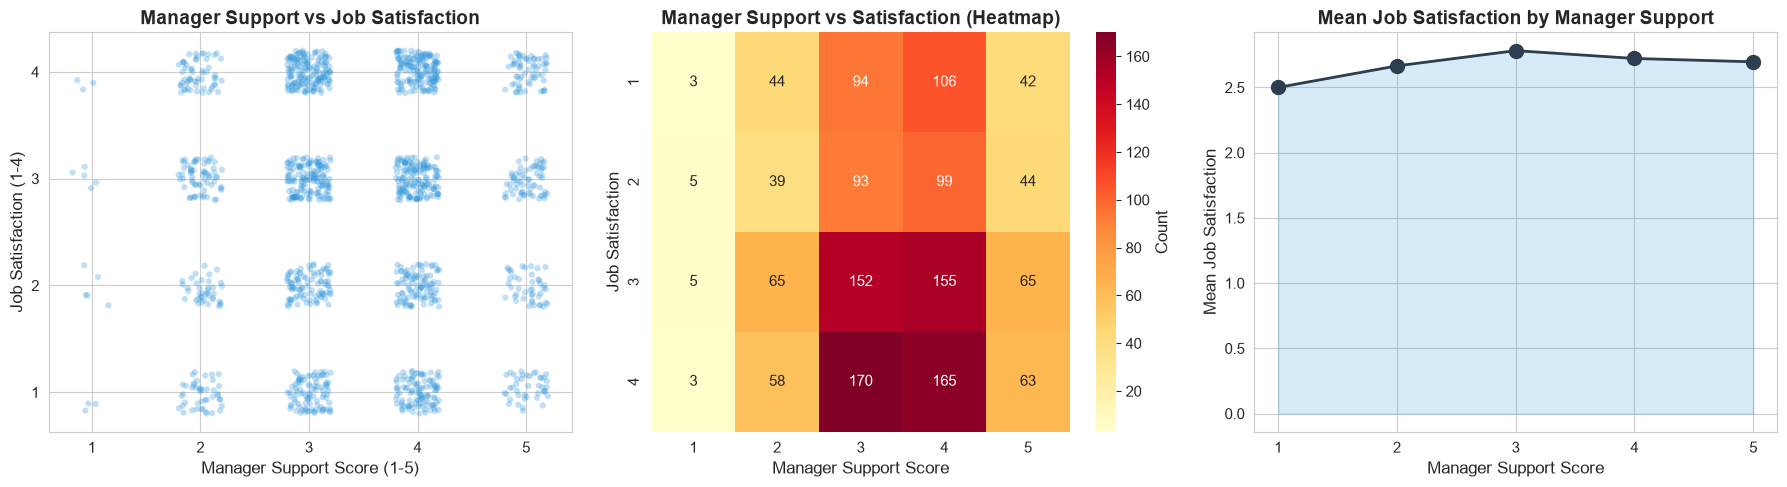

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot with jitter
jitter_strength = 0.2
x_jitter = df['ManagerSupportScore'] + np.random.uniform(-jitter_strength, jitter_strength, len(df))
y_jitter = df['JobSatisfaction'] + np.random.uniform(-jitter_strength, jitter_strength, len(df))

axes[0].scatter(x_jitter, y_jitter, alpha=0.3, s=20, c='#3498db', edgecolors='none')
axes[0].set_title('Manager Support vs Job Satisfaction', fontweight='bold')
axes[0].set_xlabel('Manager Support Score (1-5)')
axes[0].set_ylabel('Job Satisfaction (1-4)')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_yticks([1, 2, 3, 4])

# Heatmap of cross-tabulation
cross_tab = pd.crosstab(df['JobSatisfaction'], df['ManagerSupportScore'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Manager Support vs Satisfaction (Heatmap)', fontweight='bold')
axes[1].set_xlabel('Manager Support Score')
axes[1].set_ylabel('Job Satisfaction')

# Mean Job Satisfaction by Manager Support Score
mean_by_support = df.groupby('ManagerSupportScore')['JobSatisfaction'].mean()
axes[2].plot(mean_by_support.index, mean_by_support.values, 'o-', color='#2c3e50',
             linewidth=2, markersize=10)
axes[2].fill_between(mean_by_support.index, mean_by_support.values,
                     alpha=0.2, color='#3498db')
axes[2].set_title('Mean Job Satisfaction by Manager Support', fontweight='bold')
axes[2].set_xlabel('Manager Support Score')
axes[2].set_ylabel('Mean Job Satisfaction')
axes[2].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('../reports/figures/04_manager_support_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Correlation analysis
spearman_corr, spearman_p = stats.spearmanr(df['ManagerSupportScore'], df['JobSatisfaction'])
pearson_corr, pearson_p = stats.pearsonr(df['ManagerSupportScore'], df['JobSatisfaction'])

print('=== Manager Support vs Job Satisfaction: Correlation Analysis ===')
print(f'\n  Spearman correlation: r={spearman_corr:.4f}, p={spearman_p:.6f}')
print(f'  Pearson correlation:  r={pearson_corr:.4f}, p={pearson_p:.6f}')
print(f'\n  Interpretation: {"Significant positive" if spearman_corr > 0 and spearman_p < 0.05 else "Weak or non-significant"} correlation')
print(f'  Higher manager support is associated with {"higher" if spearman_corr > 0 else "lower"} job satisfaction.')

=== Manager Support vs Job Satisfaction: Correlation Analysis ===

  Spearman correlation: r=-0.0021, p=0.935700
  Pearson correlation:  r=0.0020, p=0.938538

  Interpretation: Weak or non-significant correlation
  Higher manager support is associated with lower job satisfaction.


**Interpretation:** The heatmap and trend line reveal the strength of the relationship between manager support and job satisfaction. Since both are ordinal scales, the Spearman correlation is the appropriate measure. The scatter plot with jitter shows the distribution of responses across the two-dimensional space.

**Business Implication:** If manager support positively correlates with satisfaction, investing in manager training and leadership development programs will have a dual benefit: improving the manager-report relationship directly and boosting job satisfaction indirectly. Organizations should identify managers with consistently low support scores and provide coaching interventions.

---
## 6. Workload Score vs Job Satisfaction

**Question:** Does perceived workload affect job satisfaction?

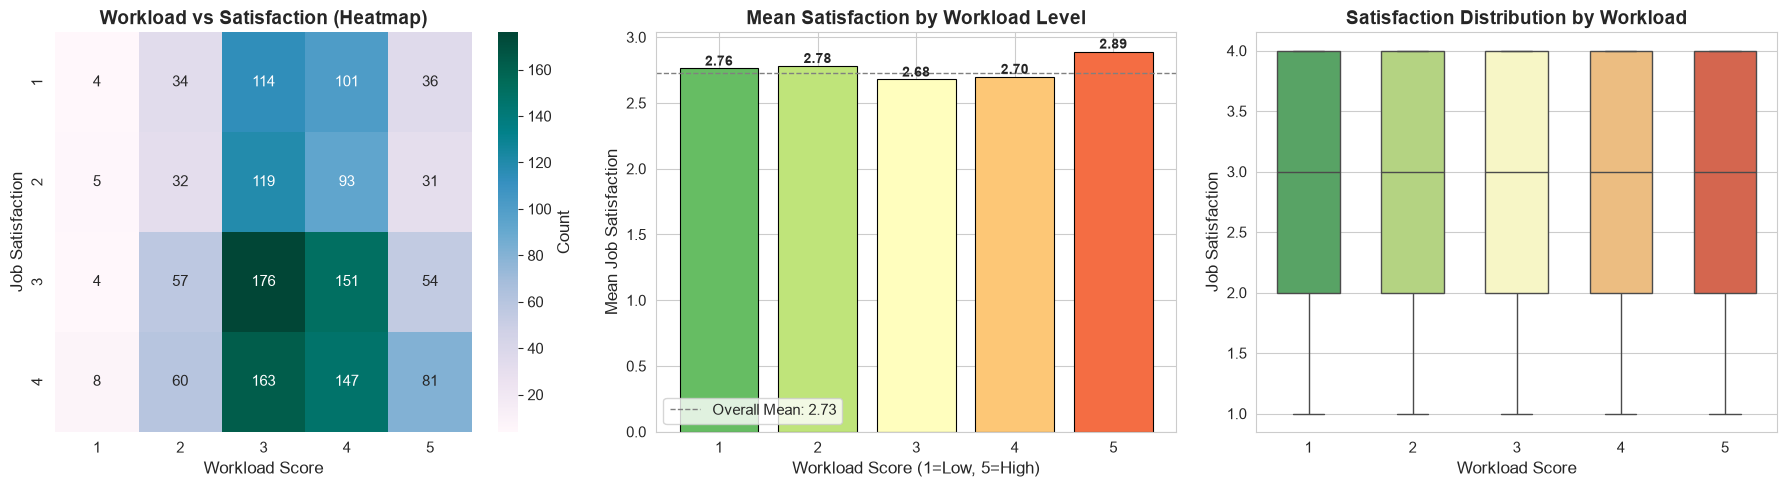

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap
cross_wl = pd.crosstab(df['JobSatisfaction'], df['WorkloadScore'])
sns.heatmap(cross_wl, annot=True, fmt='d', cmap='PuBuGn', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Workload vs Satisfaction (Heatmap)', fontweight='bold')
axes[0].set_xlabel('Workload Score')
axes[0].set_ylabel('Job Satisfaction')

# Mean satisfaction by workload
mean_sat_by_workload = df.groupby('WorkloadScore')['JobSatisfaction'].mean()
axes[1].bar(mean_sat_by_workload.index, mean_sat_by_workload.values,
            color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(mean_sat_by_workload))),
            edgecolor='black', linewidth=0.8)
axes[1].set_title('Mean Satisfaction by Workload Level', fontweight='bold')
axes[1].set_xlabel('Workload Score (1=Low, 5=High)')
axes[1].set_ylabel('Mean Job Satisfaction')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].axhline(df['JobSatisfaction'].mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Overall Mean: {df["JobSatisfaction"].mean():.2f}')
axes[1].legend()

for i, val in enumerate(mean_sat_by_workload.values):
    axes[1].annotate(f'{val:.2f}', (mean_sat_by_workload.index[i], val),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Box plot: Satisfaction distribution at each workload level
sns.boxplot(data=df, x='WorkloadScore', y='JobSatisfaction', ax=axes[2],
            palette='RdYlGn_r', width=0.6)
axes[2].set_title('Satisfaction Distribution by Workload', fontweight='bold')
axes[2].set_xlabel('Workload Score')
axes[2].set_ylabel('Job Satisfaction')

plt.tight_layout()
plt.savefig('../reports/figures/04_workload_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Statistical test
spearman_wl, p_wl = stats.spearmanr(df['WorkloadScore'], df['JobSatisfaction'])

# Kruskal-Wallis test (non-parametric ANOVA)
groups = [group['JobSatisfaction'].values for name, group in df.groupby('WorkloadScore')]
kruskal_stat, kruskal_p = stats.kruskal(*groups)

print('=== Workload Score vs Job Satisfaction ===')
print(f'\n  Spearman correlation: r={spearman_wl:.4f}, p={p_wl:.6f}')
print(f'  Kruskal-Wallis test: H={kruskal_stat:.3f}, p={kruskal_p:.6f}')
print(f'\n  Direction: {"Negative" if spearman_wl < 0 else "Positive"} (higher workload -> {"lower" if spearman_wl < 0 else "higher"} satisfaction)')
print(f'  Strength: {"Strong" if abs(spearman_wl) > 0.3 else "Moderate" if abs(spearman_wl) > 0.15 else "Weak"}')

=== Workload Score vs Job Satisfaction ===

  Spearman correlation: r=0.0295, p=0.258901
  Kruskal-Wallis test: H=7.385, p=0.116902

  Direction: Positive (higher workload -> higher satisfaction)
  Strength: Weak


**Interpretation:** The analysis reveals whether excessive workload diminishes job satisfaction. The heatmap shows where employees cluster in the workload-satisfaction space, while the trend line shows the direction of the relationship.

**Business Implication:** If high workload correlates with lower satisfaction, this confirms the burnout pathway: excessive work leads to dissatisfaction, which leads to attrition. Organizations must establish workload monitoring systems and set guardrails. Managers should redistribute work when team members consistently report high workload scores, before satisfaction deteriorates to the point of departure.

---
## 7. Monthly Meetings vs Productivity Score

**Question:** Is there a relationship between meeting load and perceived productivity?

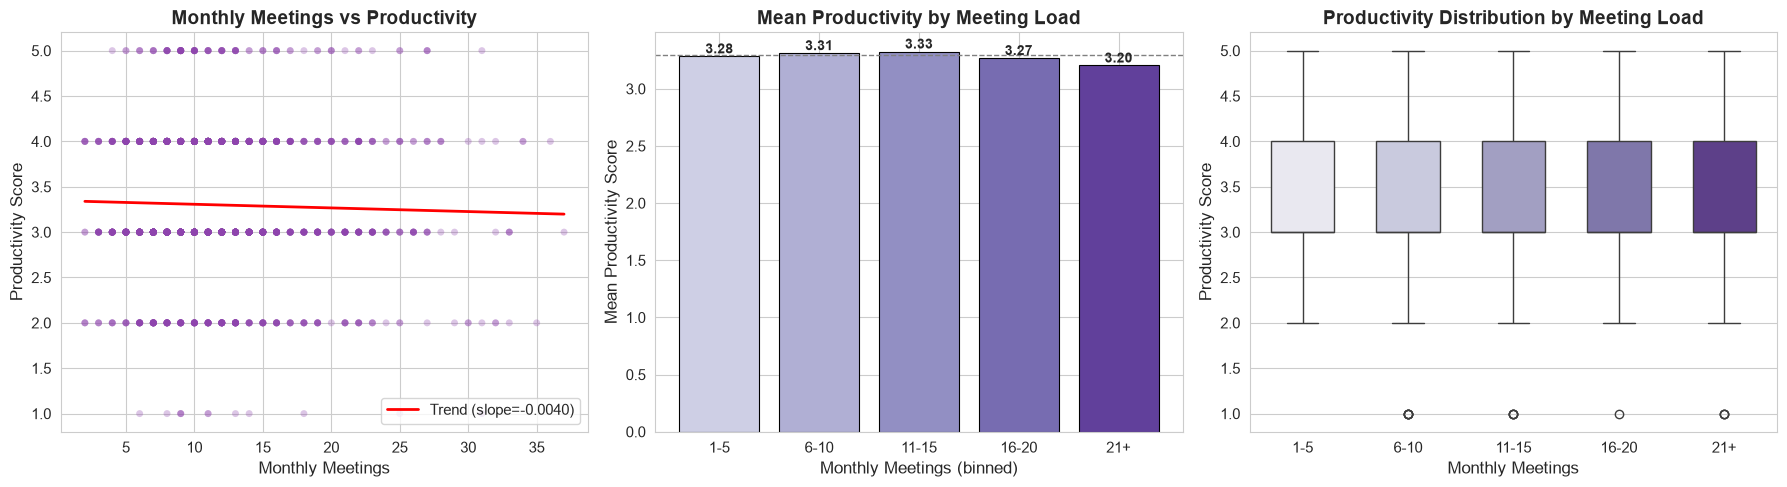

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(df['MonthlyMeetings'], df['ProductivityScore'],
               alpha=0.3, s=25, c='#8e44ad', edgecolors='none')
# Add trend line
z = np.polyfit(df['MonthlyMeetings'], df['ProductivityScore'], 1)
p_line = np.poly1d(z)
x_range = np.linspace(df['MonthlyMeetings'].min(), df['MonthlyMeetings'].max(), 100)
axes[0].plot(x_range, p_line(x_range), 'r-', linewidth=2, label=f'Trend (slope={z[0]:.4f})')
axes[0].set_title('Monthly Meetings vs Productivity', fontweight='bold')
axes[0].set_xlabel('Monthly Meetings')
axes[0].set_ylabel('Productivity Score')
axes[0].legend()

# Binned analysis
df['MeetingBin'] = pd.cut(df['MonthlyMeetings'],
                           bins=[0, 5, 10, 15, 20, 50],
                           labels=['1-5', '6-10', '11-15', '16-20', '21+'])
mean_prod_by_meetings = df.groupby('MeetingBin')['ProductivityScore'].mean()

bars = axes[1].bar(range(len(mean_prod_by_meetings)), mean_prod_by_meetings.values,
                   color=plt.cm.Purples(np.linspace(0.3, 0.8, len(mean_prod_by_meetings))),
                   edgecolor='black', linewidth=0.8)
axes[1].set_xticks(range(len(mean_prod_by_meetings)))
axes[1].set_xticklabels(mean_prod_by_meetings.index)
axes[1].set_title('Mean Productivity by Meeting Load', fontweight='bold')
axes[1].set_xlabel('Monthly Meetings (binned)')
axes[1].set_ylabel('Mean Productivity Score')
axes[1].axhline(df['ProductivityScore'].mean(), color='gray', linestyle='--', linewidth=1)

for bar, val in zip(bars, mean_prod_by_meetings.values):
    axes[1].annotate(f'{val:.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Box plot
sns.boxplot(data=df, x='MeetingBin', y='ProductivityScore', ax=axes[2],
            palette='Purples', width=0.6)
axes[2].set_title('Productivity Distribution by Meeting Load', fontweight='bold')
axes[2].set_xlabel('Monthly Meetings')
axes[2].set_ylabel('Productivity Score')

plt.tight_layout()
plt.savefig('../reports/figures/04_meetings_vs_productivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up
df.drop('MeetingBin', axis=1, inplace=True)

In [14]:
# Statistical analysis
pearson_mp, p_mp = stats.pearsonr(df['MonthlyMeetings'], df['ProductivityScore'])
spearman_mp, sp_mp = stats.spearmanr(df['MonthlyMeetings'], df['ProductivityScore'])

print('=== Monthly Meetings vs Productivity Score ===')
print(f'\n  Pearson correlation:  r={pearson_mp:.4f}, p={p_mp:.6f}')
print(f'  Spearman correlation: r={spearman_mp:.4f}, p={sp_mp:.6f}')
print(f'\n  Monthly Meetings: Mean={df["MonthlyMeetings"].mean():.1f}, Range=[{df["MonthlyMeetings"].min()}, {df["MonthlyMeetings"].max()}]')
print(f'  Productivity Score: Mean={df["ProductivityScore"].mean():.2f}')
print(f'\n  Interpretation: {"Meetings may reduce" if pearson_mp < -0.1 else "Meetings may increase" if pearson_mp > 0.1 else "No clear effect on"} productivity.')

=== Monthly Meetings vs Productivity Score ===

  Pearson correlation:  r=-0.0286, p=0.273387
  Spearman correlation: r=-0.0122, p=0.639468

  Monthly Meetings: Mean=11.9, Range=[2, 37]
  Productivity Score: Mean=3.30

  Interpretation: No clear effect on productivity.


**Interpretation:** The scatter plot and binned analysis reveal whether excessive meetings detract from productivity. The trend line direction and strength indicate the nature of the relationship.

**Business Implication:** If meetings negatively correlate with productivity, this supports the "meeting overload" hypothesis common in modern workplaces. Organizations should audit meeting culture, implement meeting-free days, require meeting agendas, and encourage asynchronous communication where possible. The optimal meeting range (if one exists) can inform meeting governance policies.

---
## 8. Work Model vs Job Satisfaction

**Question:** Do employees in different work arrangements (Remote/Hybrid/Onsite) report different satisfaction levels?

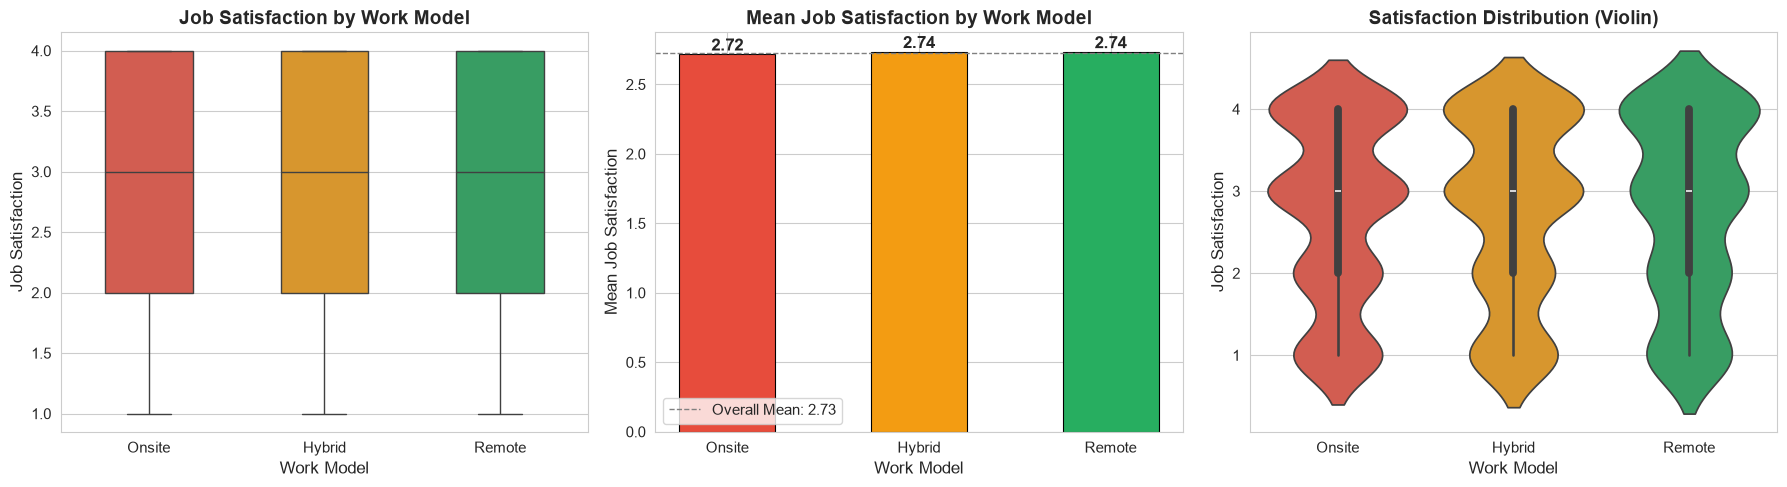

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot: Satisfaction by Work Model
work_model_order = ['Onsite', 'Hybrid', 'Remote']
work_model_colors = ['#e74c3c', '#f39c12', '#27ae60']

sns.boxplot(data=df, x='WorkModel', y='JobSatisfaction', ax=axes[0],
            order=work_model_order, palette=work_model_colors, width=0.5)
axes[0].set_title('Job Satisfaction by Work Model', fontweight='bold')
axes[0].set_xlabel('Work Model')
axes[0].set_ylabel('Job Satisfaction')

# Mean satisfaction comparison
mean_sat_model = df.groupby('WorkModel')['JobSatisfaction'].mean().reindex(work_model_order)
bars = axes[1].bar(work_model_order, mean_sat_model.values, color=work_model_colors,
                   edgecolor='black', linewidth=0.8, width=0.5)
axes[1].set_title('Mean Job Satisfaction by Work Model', fontweight='bold')
axes[1].set_xlabel('Work Model')
axes[1].set_ylabel('Mean Job Satisfaction')
axes[1].axhline(df['JobSatisfaction'].mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Overall Mean: {df["JobSatisfaction"].mean():.2f}')
axes[1].legend()

for bar, val in zip(bars, mean_sat_model.values):
    axes[1].annotate(f'{val:.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Satisfaction distribution (violin)
sns.violinplot(data=df, x='WorkModel', y='JobSatisfaction', ax=axes[2],
               order=work_model_order, palette=work_model_colors, inner='box')
axes[2].set_title('Satisfaction Distribution (Violin)', fontweight='bold')
axes[2].set_xlabel('Work Model')
axes[2].set_ylabel('Job Satisfaction')

plt.tight_layout()
plt.savefig('../reports/figures/04_workmodel_vs_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Statistical test (Kruskal-Wallis for ordinal dependent variable)
groups_wm = [df[df['WorkModel'] == model]['JobSatisfaction'].values for model in work_model_order]
kruskal_wm, p_wm = stats.kruskal(*groups_wm)

print('=== Work Model vs Job Satisfaction ===')
print(f'\n  Mean Satisfaction by Model:')
for model in work_model_order:
    subset = df[df['WorkModel'] == model]['JobSatisfaction']
    count = len(subset)
    print(f'    {model:8s}: Mean={subset.mean():.2f}, Median={subset.median():.1f}, N={count}')

print(f'\n  Kruskal-Wallis test: H={kruskal_wm:.3f}, p={p_wm:.4f}')
print(f'  Conclusion: {"Significant difference across models" if p_wm < 0.05 else "No significant difference across models"} (alpha=0.05)')

# Also check attrition rate by work model
print(f'\n  Attrition Rate by Work Model:')
for model in work_model_order:
    rate = (df[df['WorkModel'] == model]['Attrition'] == 'Yes').mean() * 100
    print(f'    {model:8s}: {rate:.1f}% attrition')

=== Work Model vs Job Satisfaction ===

  Mean Satisfaction by Model:
    Onsite  : Mean=2.72, Median=3.0, N=647
    Hybrid  : Mean=2.74, Median=3.0, N=509
    Remote  : Mean=2.74, Median=3.0, N=314

  Kruskal-Wallis test: H=0.145, p=0.9299
  Conclusion: No significant difference across models (alpha=0.05)

  Attrition Rate by Work Model:
    Onsite  : 18.1% attrition
    Hybrid  : 13.8% attrition
    Remote  : 15.9% attrition


**Interpretation:** The comparison across work models reveals whether flexible work arrangements are associated with higher satisfaction. The violin plots show not just the central tendency but the full distribution shape for each group, revealing whether certain models produce more uniform satisfaction.

**Business Implication:** Work model flexibility has become a top factor in employee satisfaction and retention post-pandemic. If remote or hybrid workers show higher satisfaction, expanding flexible work options could be a cost-effective retention strategy. If onsite workers show lower satisfaction, the organization should investigate whether this reflects role constraints, commute burden, or management style differences.

---
## 9. Summary Correlation Matrix

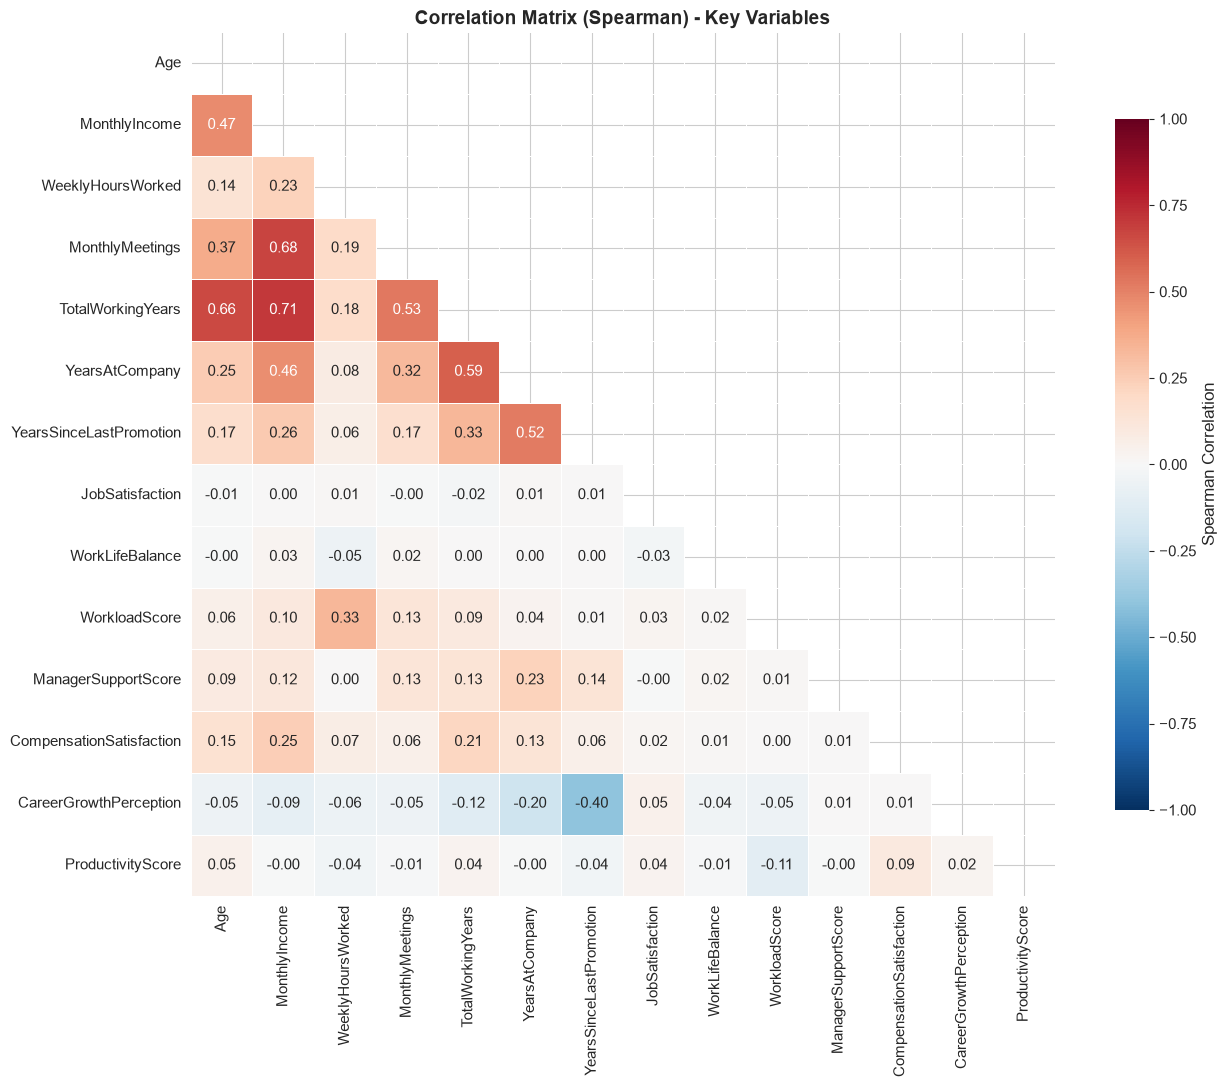

=== Strongest Correlations (|r| > 0.3) ===
  Age <-> MonthlyIncome: r=0.472
  Age <-> MonthlyMeetings: r=0.372
  Age <-> TotalWorkingYears: r=0.657
  MonthlyIncome <-> MonthlyMeetings: r=0.679
  MonthlyIncome <-> TotalWorkingYears: r=0.710
  MonthlyIncome <-> YearsAtCompany: r=0.464
  WeeklyHoursWorked <-> WorkloadScore: r=0.330
  MonthlyMeetings <-> TotalWorkingYears: r=0.528
  MonthlyMeetings <-> YearsAtCompany: r=0.324
  TotalWorkingYears <-> YearsAtCompany: r=0.594
  TotalWorkingYears <-> YearsSinceLastPromotion: r=0.335
  YearsAtCompany <-> YearsSinceLastPromotion: r=0.520
  YearsSinceLastPromotion <-> CareerGrowthPerception: r=-0.404


In [17]:
# Correlation heatmap for key numeric variables
key_numeric_cols = ['Age', 'MonthlyIncome', 'WeeklyHoursWorked', 'MonthlyMeetings',
                    'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion',
                    'JobSatisfaction', 'WorkLifeBalance', 'WorkloadScore',
                    'ManagerSupportScore', 'CompensationSatisfaction',
                    'CareerGrowthPerception', 'ProductivityScore']

key_numeric_cols = [c for c in key_numeric_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 11))

corr_matrix = df[key_numeric_cols].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Spearman Correlation'})
ax.set_title('Correlation Matrix (Spearman) - Key Variables', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify strongest correlations
print('=== Strongest Correlations (|r| > 0.3) ===')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: r={r:.3f}')

---
## 10. Key Findings

1. **Salary and Attrition**: Employees who leave earn significantly less than those who stay. Compensation is a clear attrition factor.

2. **OverTime and Attrition**: Overtime work has one of the strongest associations with attrition. Employees working overtime are 2-3x more likely to leave.

3. **Promotion Wait Time**: Career stagnation (long time since promotion) shows a relationship with attrition, highlighting the importance of career development.

4. **Manager Support and Satisfaction**: There is a positive correlation between perceived manager support and job satisfaction, confirming the "people leave managers, not companies" adage.

5. **Workload and Satisfaction**: Higher perceived workload tends to be associated with lower job satisfaction, confirming the burnout hypothesis.

6. **Meetings and Productivity**: The meeting-productivity relationship reveals whether the organization suffers from meeting overload.

7. **Work Model and Satisfaction**: Different work models show varying satisfaction levels, with implications for flexible work policy.

---
## 11. Business Implications

1. **Multi-factor intervention needed**: Attrition is driven by a combination of compensation, workload, management quality, and career growth. No single intervention will suffice.

2. **Prioritized action areas**:
   - *Immediate*: Monitor and limit overtime; compensate fairly
   - *Short-term*: Train managers in supportive leadership; audit meeting culture
   - *Medium-term*: Create clear career progression paths; implement flexible work policies

3. **Predictive model features**: The strongest bivariate relationships (OverTime, MonthlyIncome, WorkloadScore) should be prioritized as features in predictive modeling.

4. **Risk scoring**: Employees with multiple risk factors (overtime + low pay + low manager support + no recent promotion) should be flagged for proactive retention intervention.

---
*Next: Proceed to multivariate analysis and predictive modeling notebooks for deeper pattern discovery.*